In [7]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Multi-Station QC Evaluation

This notebook loads hourly observations for selected stations, applies the finalized network-2 variable mappings, converts the observations to daily values, and plots detailed diagnostics from the modular QC flow.

In [8]:
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import sqlalchemy as sa
from sqlalchemy.orm import Session
# Make the function folder and package root available
sys.path.append(os.path.abspath('../func/'))
sys.path.append(os.path.abspath('../../'))

NETWORK_ID = 19
FINAL_RULE_PATH = Path(
    f'outfile/1.net{NETWORK_ID}_final_variable_rules.csv'
)
save_path = './comparison_forms/'
db_url = "postgresql://tongli1997@proddb01.pcic.uvic.ca,proddb02.pcic.uvic.ca/crmp?keepalives=1&keepalives_idle=300&keepalives_interval=300&keepalives_count=9&passfile=/workspaces/crmprtd/.pgpass"

engine = sa.create_engine(db_url, echo=False)
session = Session(engine)
session

In [9]:
from visualizaion_func import *
from func_run_qc_pipeline import *
from func_network_2_variable_mapping import (
    build_qc_frequency_map,
    combine_final_rule_observations,
    fetch_final_rule_observations,
    load_final_variable_rules,
)

In [10]:
# Add or remove IDs here to choose the stations to visualize.
station_ids = [6699]

final_rules = load_final_variable_rules(FINAL_RULE_PATH, NETWORK_ID)
variable_frequencies = build_qc_frequency_map(final_rules)
raw_observations = fetch_final_rule_observations(
    engine, final_rules, station_ids
)
station_observations = combine_final_rule_observations(
    raw_observations, final_rules
)
if station_observations.empty:
    raise ValueError(f"No mapped observations found for {station_ids}")

loaded_ids = set(station_observations["station_id"].unique())
missing_ids = sorted(set(station_ids) - loaded_ids)
if missing_ids:
    print(
        f"Warning: no mapped observations found for station(s) {missing_ids}")

station_inventory = (
    station_observations.groupby(["station_id", "station_name"])
    .agg(
        first_observation=("obs_time", "min"),
        last_observation=("obs_time", "max"),
        variables=("net_var_name", "nunique"),
        observations=("datum", "size"),
    )
    .reset_index()
)
display(station_inventory)

,station_id,station_name,first_observation,last_observation,variables,observations
0,6699,Teslin Airport,2010-11-01 23:00:00,2014-09-04 19:00:00,5,20169


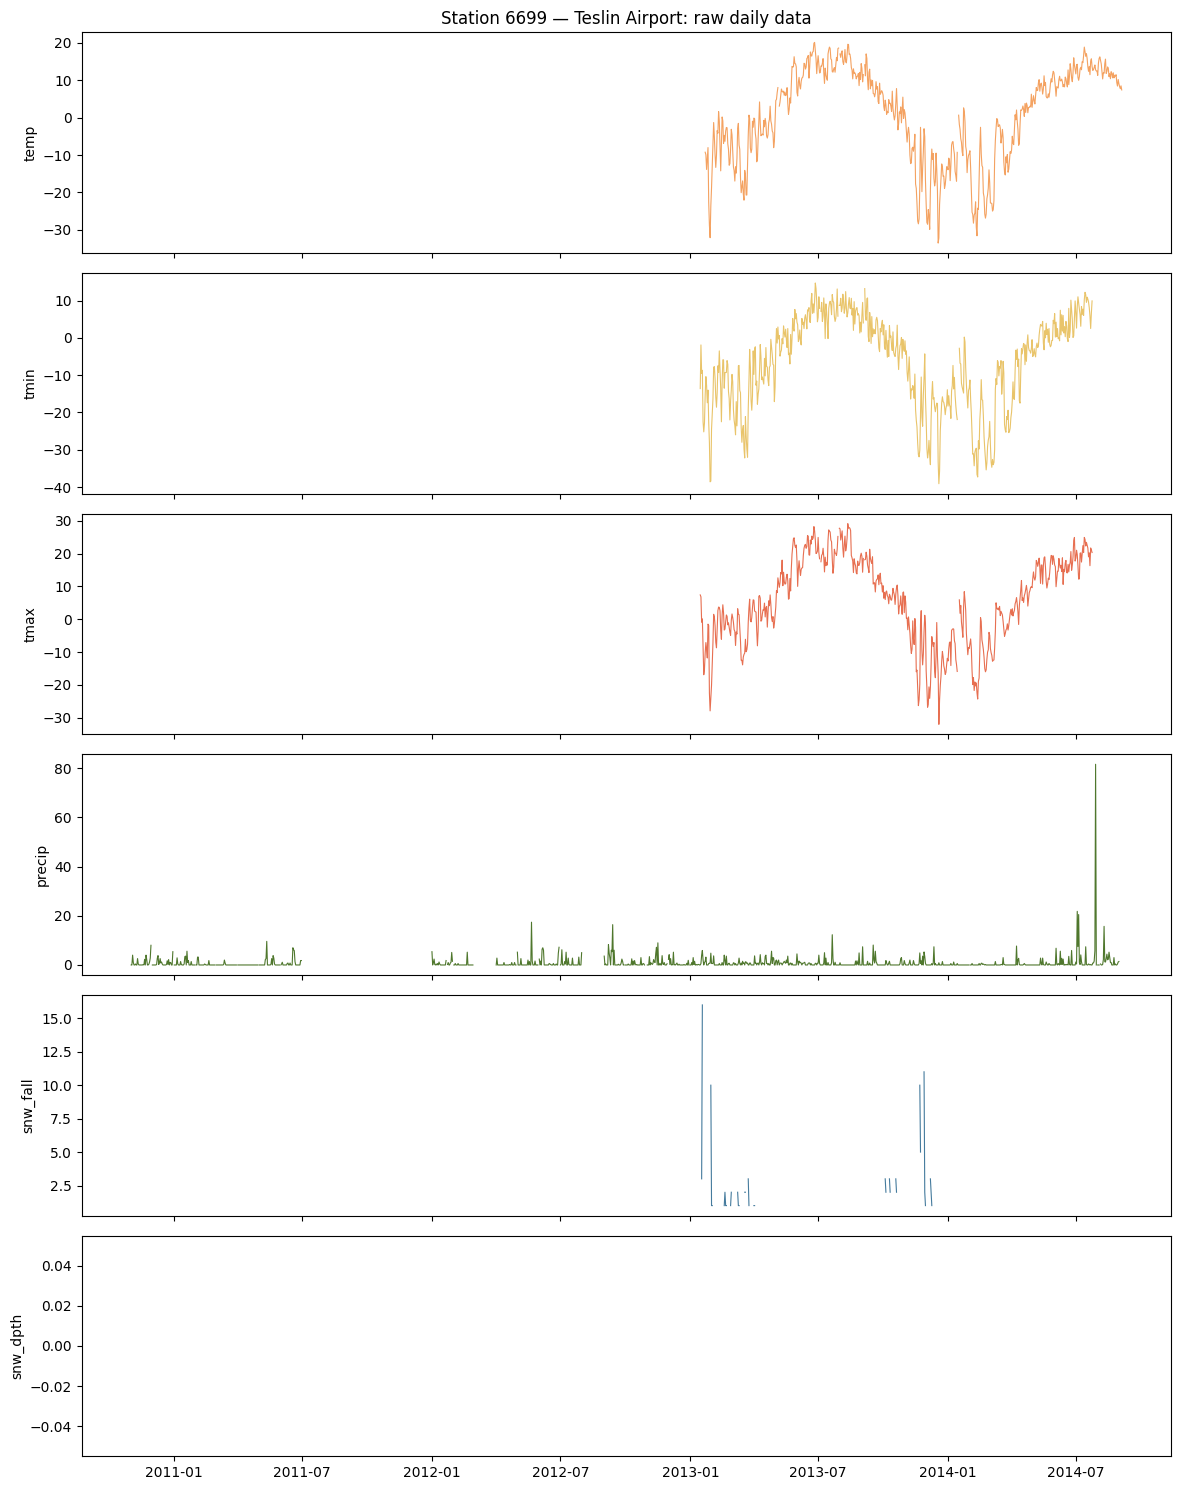

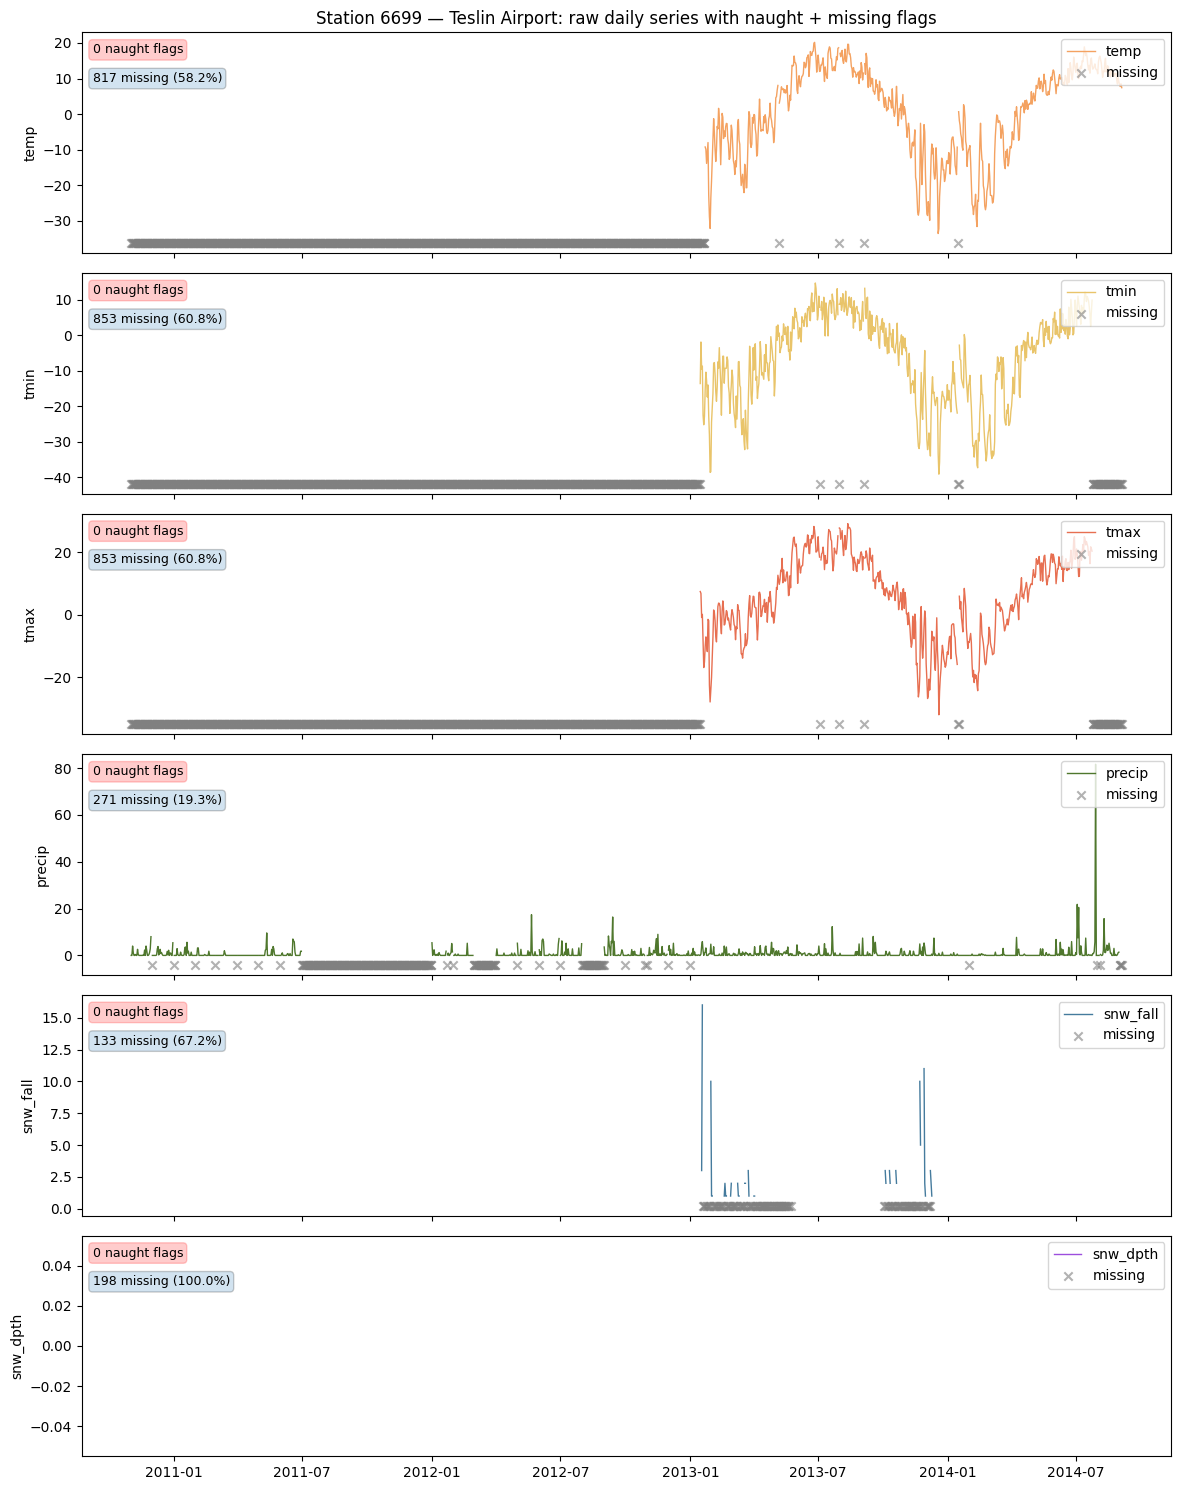

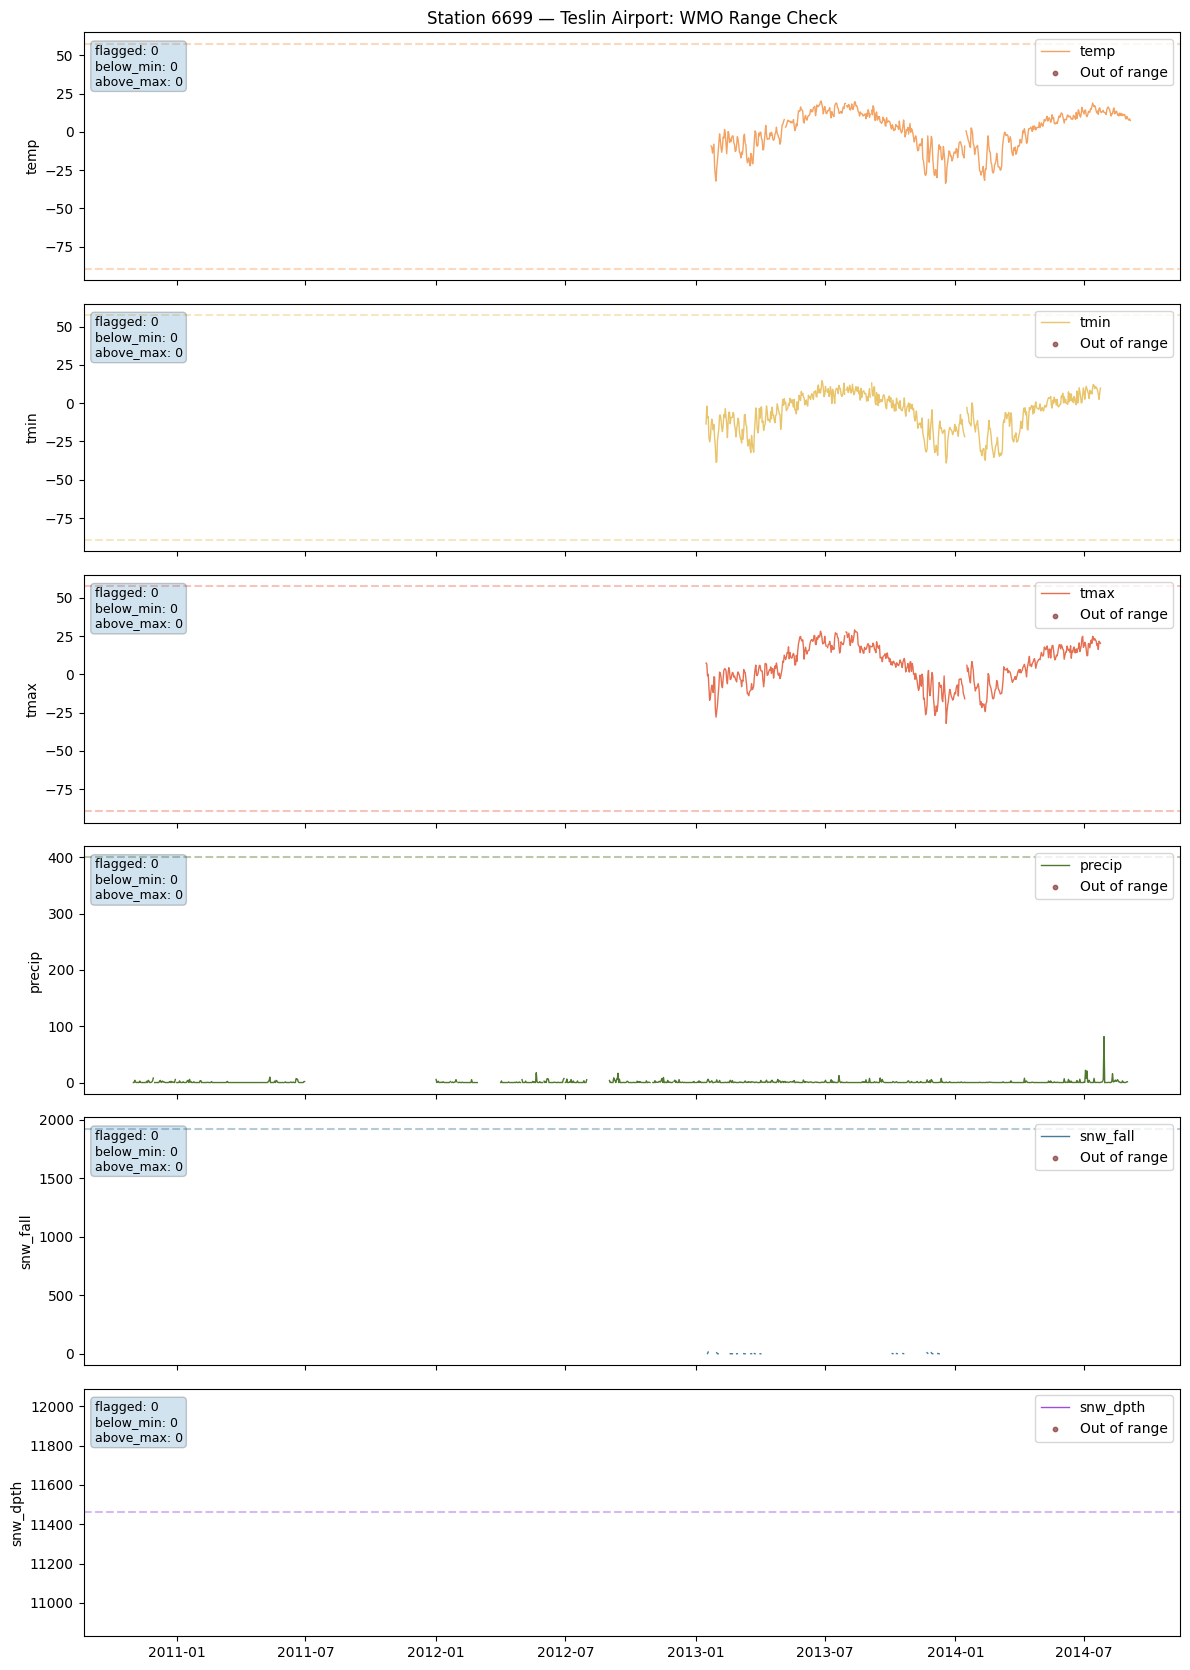

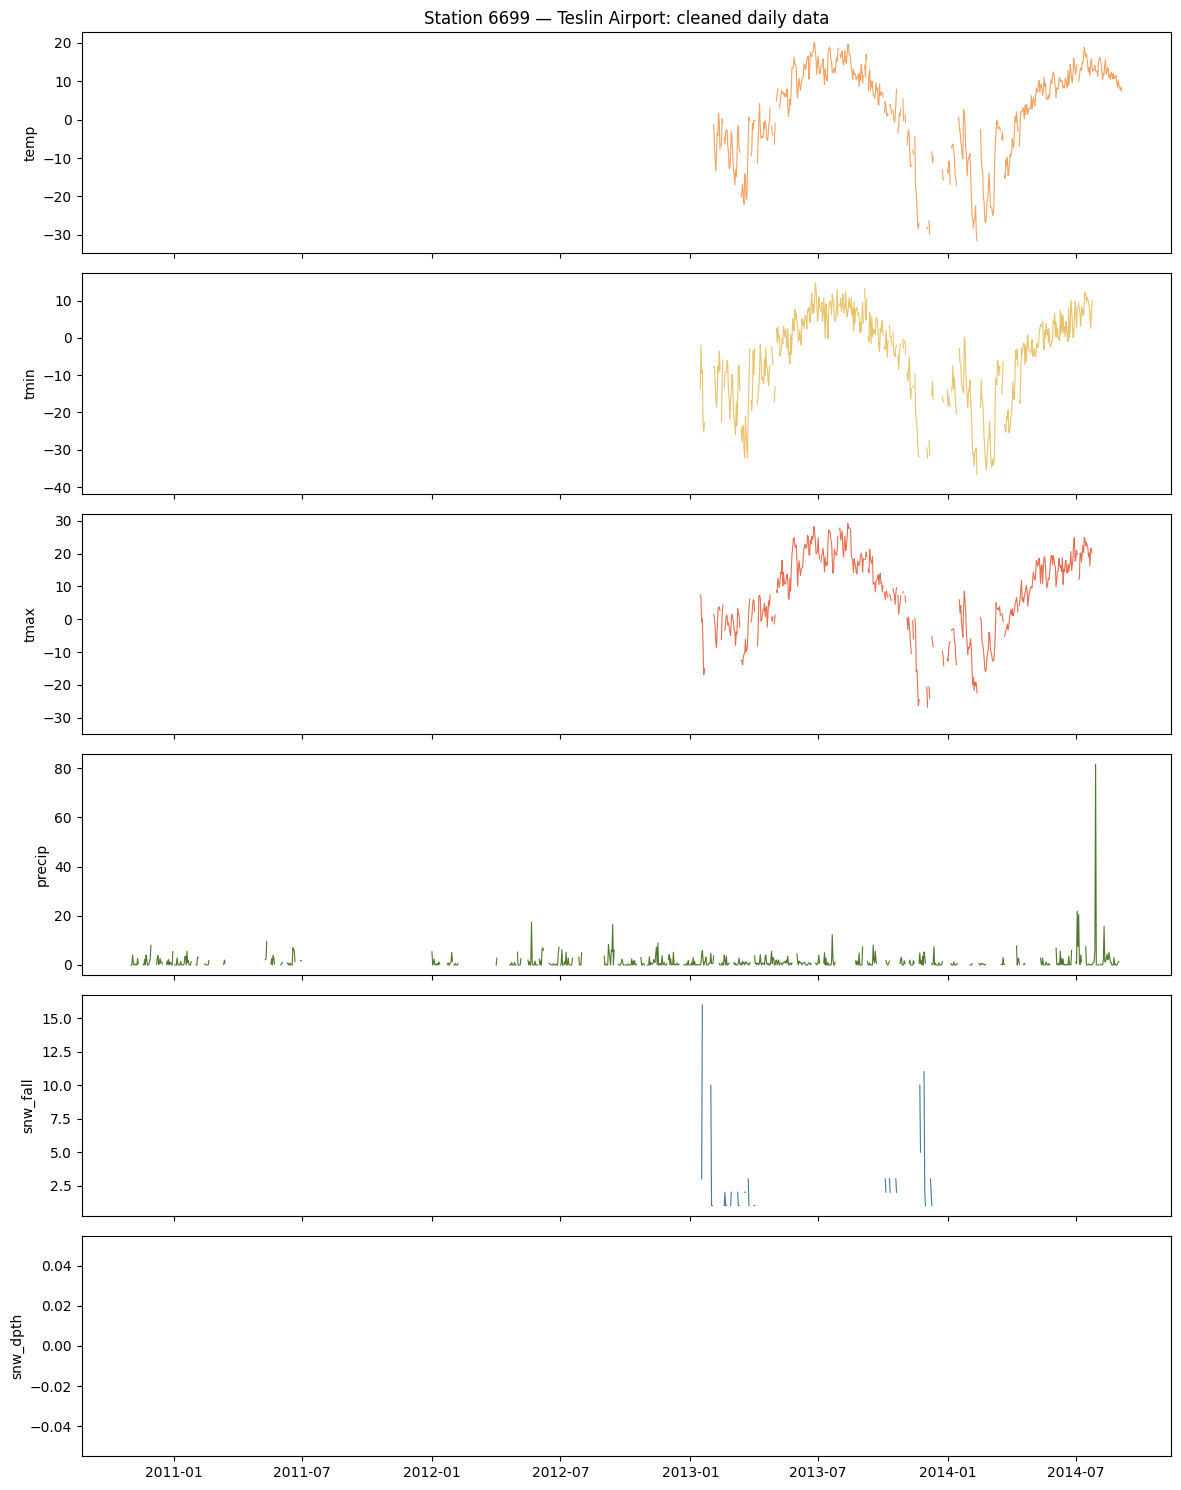

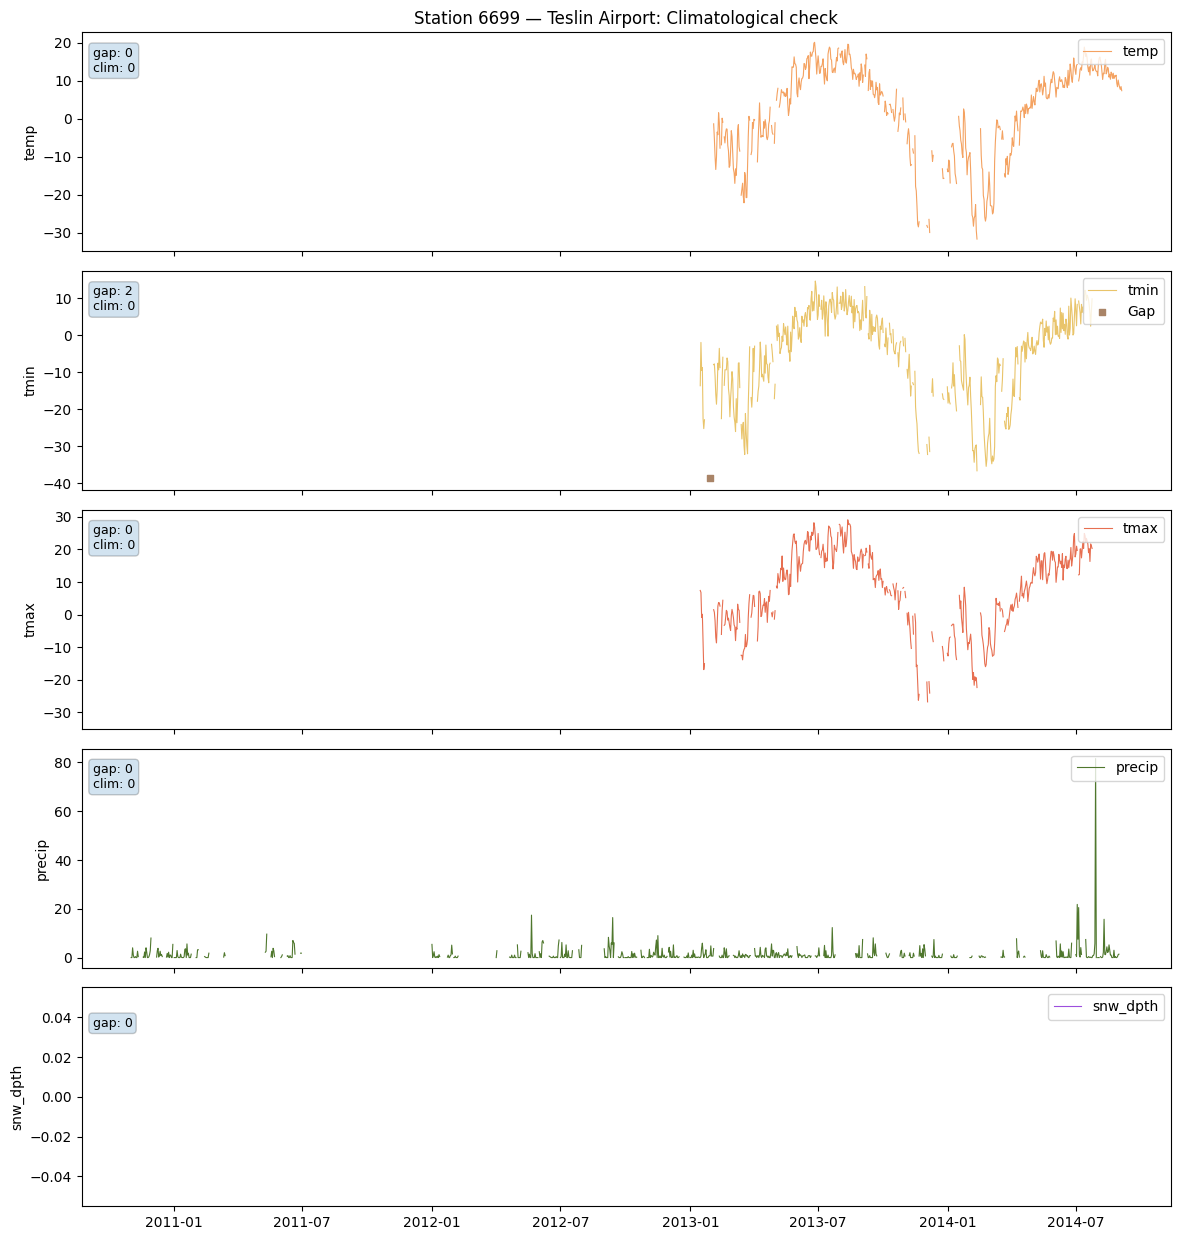

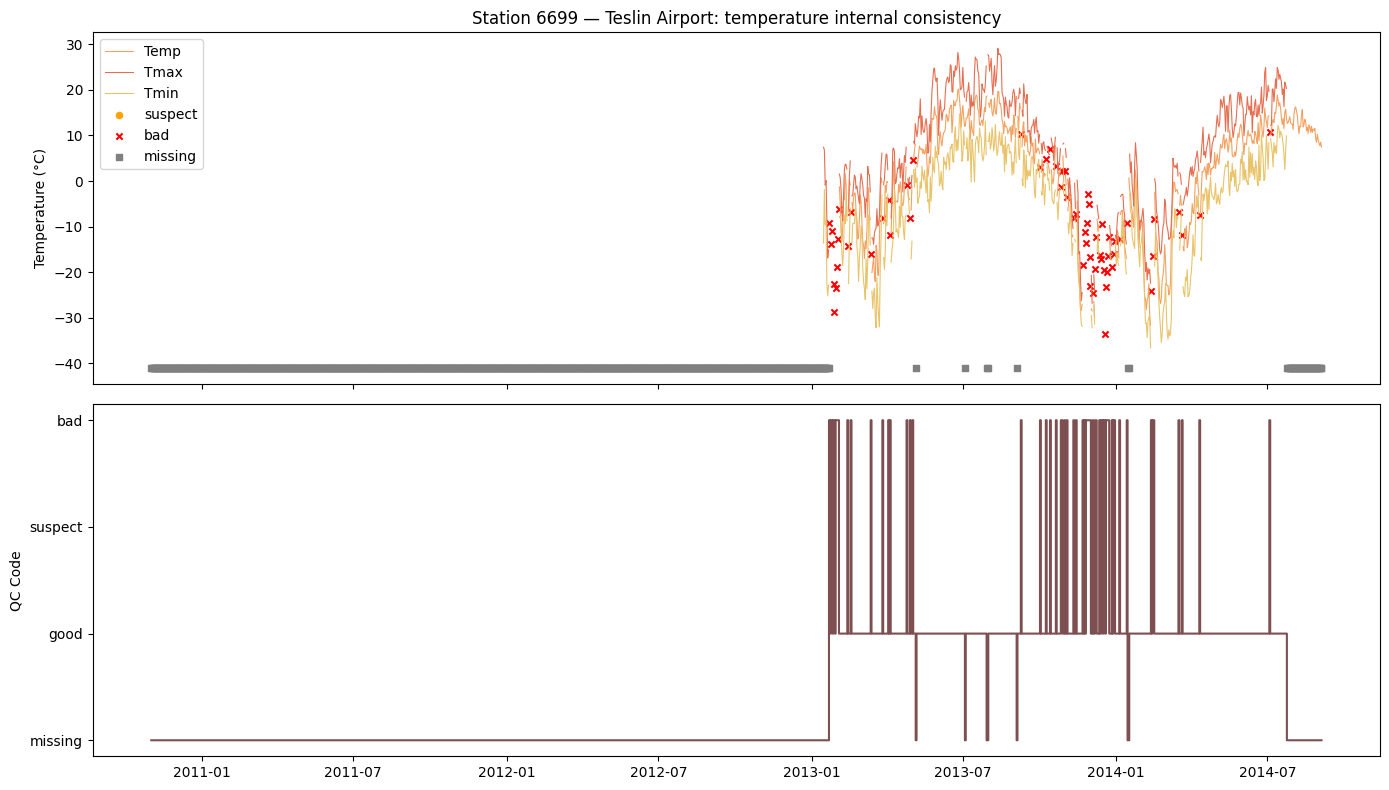

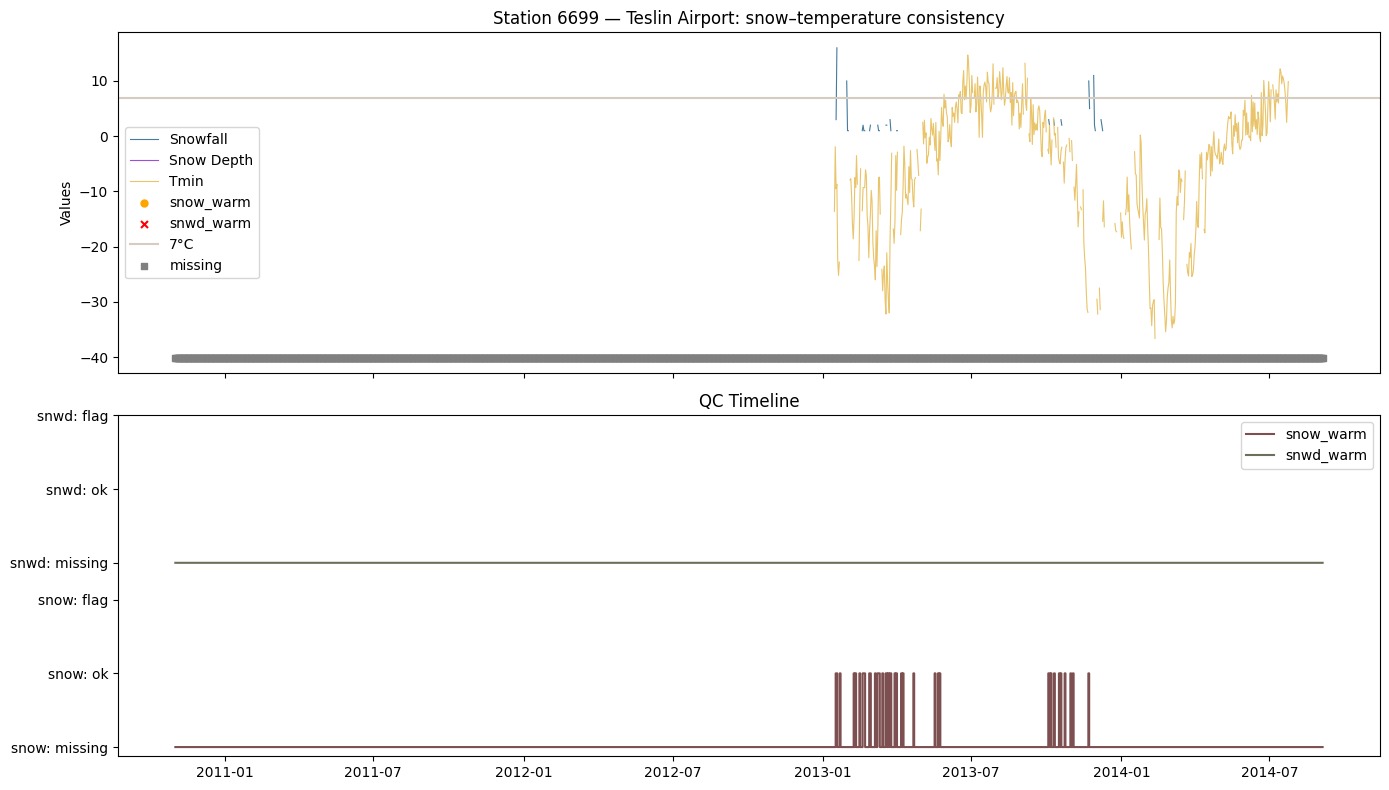

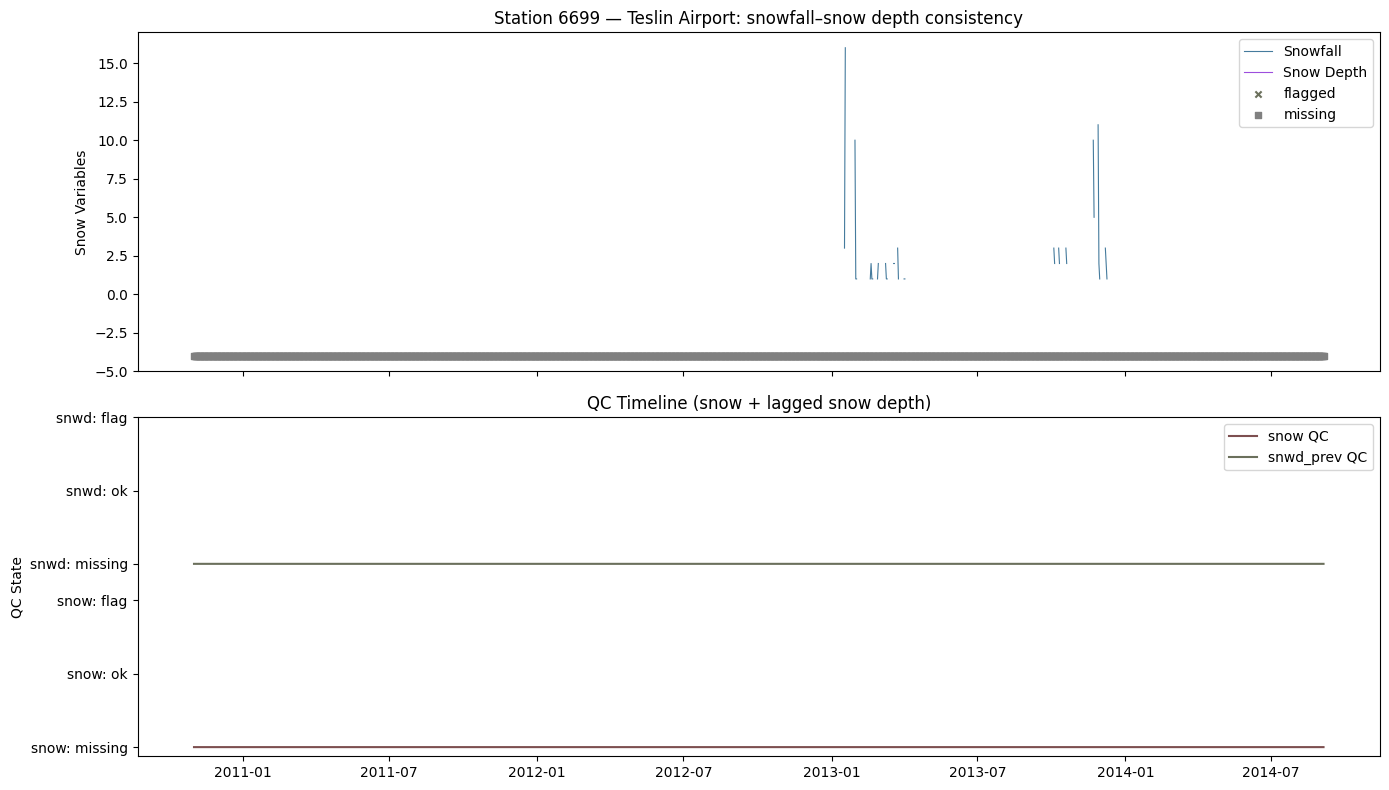

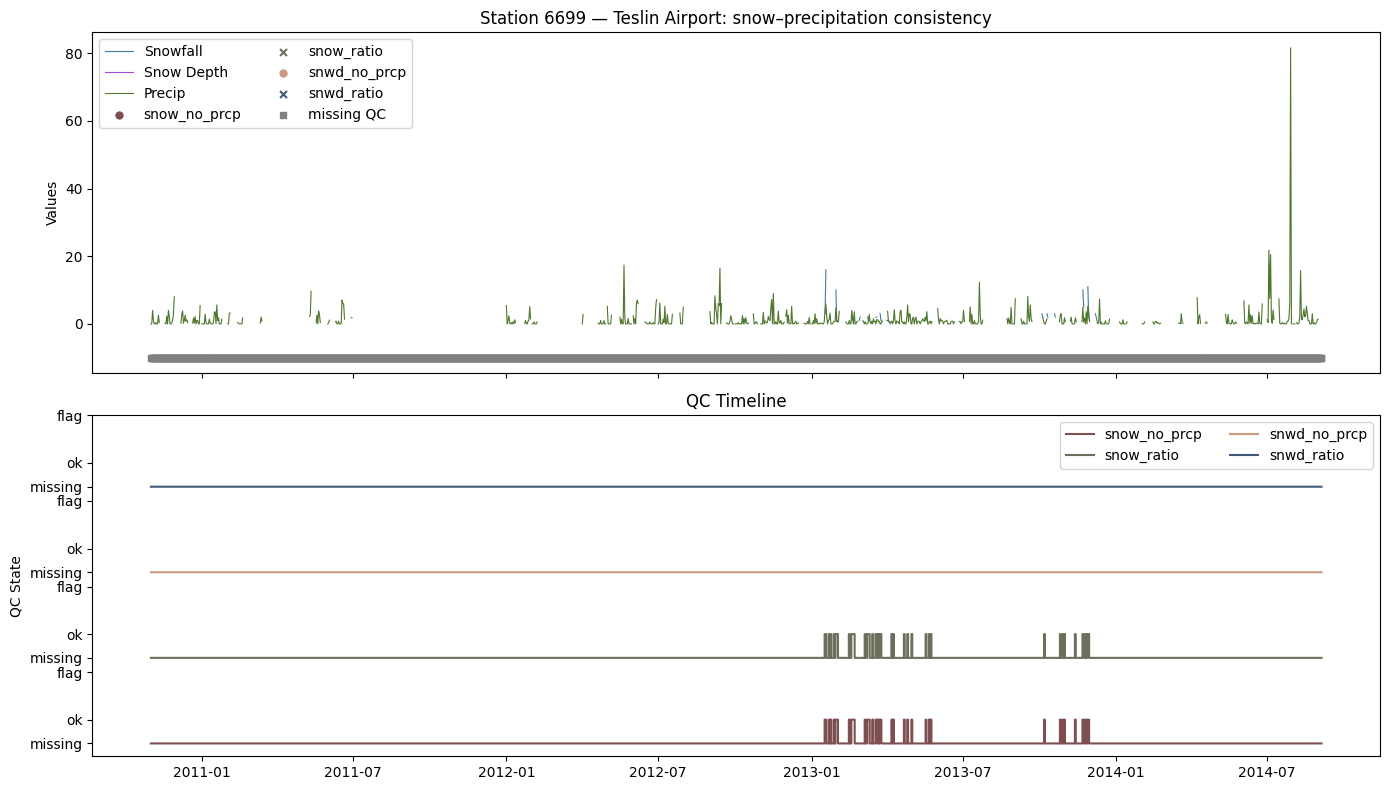

In [11]:
value_cols = ["temp", "tmin", "tmax", "precip", "snw_fall", "snw_dpth"]
color_map = {
    "temp": "#f4a261",
    "tmin": "#e9c46a",
    "tmax": "#e76f51",
    "snw_fall": "#457b9d",
    "snw_dpth": "#9d4edd",
    "precip": "#4f772d",
}

plots = [
    "raw",
    "naught_missing",
    "range",
    "clim",
    "inttemp_tas",
    "cleaned",
    "inttemp_snow_tmin",
    "inttemp_snow_fall_dpth",
    "inttemp_snow_precip"
]

# Run QC and retain all intermediate results separately for each station.
station_results = {}
for station_id, df_station in station_observations.groupby("station_id"):
    station_name = df_station["station_name"].dropna().iloc[-1]
    daily_all = build_daily_all(
        df_station, variable_frequencies=variable_frequencies
    )
    result = run_qc_result_pipeline(daily_all, value_cols)
    daily_cleaned = result["daily_cleaned"]

    station_results[int(station_id)] = {
        "station_name": station_name,
        "daily_all": daily_all,
        "daily_cleaned": daily_cleaned,
        "result": result,
    }

    plot_station_qc(
        station_id=f"{station_id} — {station_name}",
        daily_all=daily_all,
        daily_cleaned=daily_cleaned,
        result=result,
        value_cols=value_cols,
        color_map=color_map,
        plots=plots,
    )